In [1]:
import optuna
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

c:\Users\Steve\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
study = optuna.load_study(
    storage=r"sqlite:///cw.sqlite3",
    study_name="resnet_50_128img_XYZV_all",
)

In [3]:
df = study.trials_dataframe()
df = df[df.state == "COMPLETE"]
df.describe()

,number,value,datetime_start,datetime_complete,duration,params_voltage,params_x,params_y,params_z,user_attrs_attempts,user_attrs_failed
count,432.000000,432.000000,432,432,432,432.000000,432.000000,432.000000,432.000000,432.000000,432.000000
mean,216.155093,0.752927,2026-04-23 00:26:46.093120,2026-04-23 00:27:06.110075,0 days 00:00:20.016954,292.476852,121.956019,154.833333,0.291435,2.289352,0.324074
min,0.000000,0.577009,2026-04-22 21:31:37.949296,2026-04-22 21:31:49.668992,0 days 00:00:10.677796,150.000000,113.000000,148.000000,0.000000,2.000000,0.000000
25%,107.750000,0.757812,2026-04-22 21:59:59.579259,2026-04-22 22:00:30.126914,0 days 00:00:11.911664,250.000000,120.000000,153.500000,0.100000,2.000000,0.000000
50%,215.500000,0.757812,2026-04-22 22:32:58.526975,2026-04-22 22:33:13.159197,0 days 00:00:12.284067,300.000000,122.500000,155.000000,0.200000,2.000000,0.000000
75%,323.250000,0.757812,2026-04-22 23:15:32.918348,2026-04-22 23:15:44.665688,0 days 00:00:17.016071,350.000000,124.500000,156.500000,0.400000,2.000000,0.000000
max,435.000000,0.757812,2026-04-23 12:14:07.589239,2026-04-23 12:14:47.579333,0 days 00:01:45.155014,350.000000,127.000000,160.000000,1.000000,14.000000,6.000000
std,125.803023,0.024346,NaN,NaN,0 days 00:00:17.121446,60.413305,3.458123,2.341247,0.265618,1.025013,0.708958


In [4]:
df = df.explode("user_attrs_top-1")

df = df.reset_index(drop=True)

In [5]:
df = df[["params_x", "params_y", "params_z", "params_voltage", "user_attrs_top-1"]]
df.to_csv("data_full.csv", index=False)

In [6]:
df_unchanged = df[df["user_attrs_top-1"] == 0.7578125]
df_failed = df[df["user_attrs_top-1"] == -1]
df_one = df[(df["user_attrs_top-1"] != 0.7578125) & (df["user_attrs_top-1"] != -1)]
df_success = df[(df["user_attrs_top-1"] < 0.5) & (df["user_attrs_top-1"] != -1)]

In [7]:
df.head()

,params_x,params_y,params_z,params_voltage,user_attrs_top-1
0,122.5,158.5,0.35,250,0.757812
1,122.5,158.5,0.35,250,0.757812
2,126.5,153.0,0.65,350,0.757812
3,126.5,153.0,0.65,350,0.757812
4,115.5,156.0,1.00,250,0.757812


In [8]:
df_one.mode()

,params_x,params_y,params_z,params_voltage,user_attrs_top-1
0,122.5,154.5,0.15,350,0.75


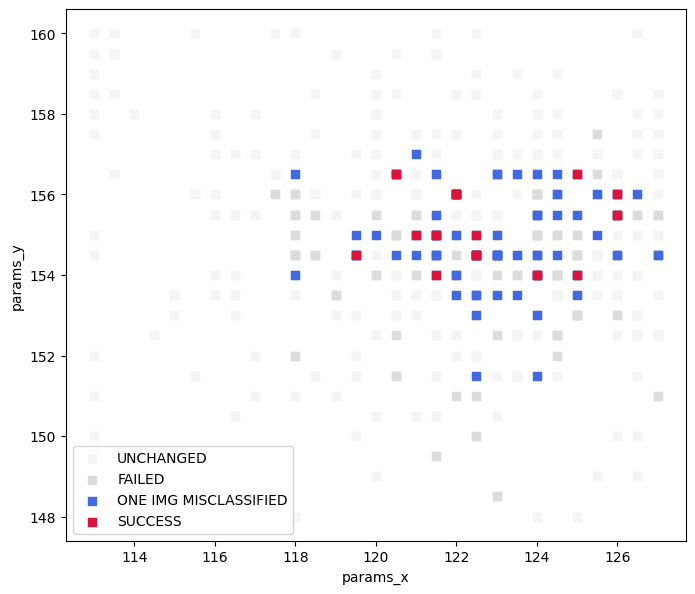

In [9]:
SCALE = 8
MARKER = 40

fig, ax = plt.subplots(figsize=(SCALE, SCALE))

ax.set_aspect("equal")

param_x = "params_x"
param_y = "params_y"

ax.scatter(
    df_unchanged[param_x],
    df_unchanged[param_y],
    c="whitesmoke",
    label="UNCHANGED",
    s=MARKER,
    marker="s",
)
ax.scatter(
    df_failed[param_x],
    df_failed[param_y],
    c="gainsboro",
    label="FAILED",
    s=MARKER,
    marker="s",
)
ax.scatter(
    df_one[param_x],
    df_one[param_y],
    c="royalblue",
    label="ONE IMG MISCLASSIFIED",
    s=MARKER,
    marker="s",
)

ax.scatter(
    df_success[param_x],
    df_success[param_y],
    c="crimson",
    label="SUCCESS",
    s=MARKER,
    marker="s",
)

ax.set_xlabel(param_x)
ax.set_ylabel(param_y)
ax.legend()

plt.savefig("2d_full.svg")

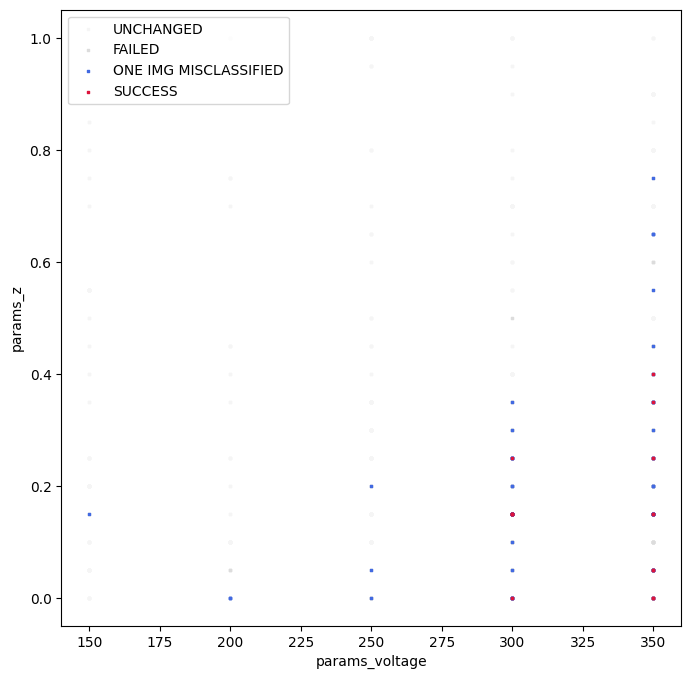

In [10]:
fig, ax = plt.subplots(figsize=(SCALE, SCALE))

# ax.set_aspect("equal")

param_x = "params_voltage"
param_y = "params_z"

ax.scatter(
    df_unchanged[param_x],
    df_unchanged[param_y],
    c="whitesmoke",
    label="UNCHANGED",
    s=1,
    marker="s",
)
ax.scatter(
    df_failed[param_x],
    df_failed[param_y],
    c="gainsboro",
    label="FAILED",
    s=1,
    marker="s",
)
ax.scatter(
    df_one[param_x],
    df_one[param_y],
    c="royalblue",
    label="ONE IMG MISCLASSIFIED",
    s=1,
    marker="s",
)
ax.scatter(
    df_success[param_x],
    df_success[param_y],
    c="crimson",
    label="SUCCESS",
    s=1,
    marker="s",
)

ax.set_xlabel(param_x)
ax.set_ylabel(param_y)
ax.legend()

plt.savefig("z_vs_voltage_full.svg")